# Mapping Colonial Resource Extraction: A GIS Analysis

This notebook builds a **geographic, data-driven companion** to the argument in Eduardo
Galeano's *Open Veins of Latin America*: that the wealth of the "developed" North was
substantially built from resources — minerals, plantation crops, and forced labor —
extracted from the Americas and Africa, and that this extraction left a lasting economic
footprint still visible in the data today.

**What's real data vs. what's illustrative here (stated upfront, no blurring):**

| Layer | Status |
|---|---|
| Country boundaries | **Real** — Natural Earth 1:110m admin-0 boundaries, fetched live from GitHub |
| GDP per capita by country/year, 1500–2018 | **Real** — Maddison Project Database 2020 (Bolt & van Zanden), fetched live |
| Trans-Atlantic slave trade volumes by 25-year period, 1501–1875 | **Real** — published SlaveVoyages.org estimates, transcribed from the project's own summary tables |
| Extraction-site locations (mines, plantation regions, boom towns) | **Real coordinates**, but the *selection* of ~15 sites is illustrative/representative, not exhaustive |
| Flow arcs (extraction site → European/US port) | **Stylized** — great-circle-ish curves for visual clarity, not actual historical shipping routes |

The notebook fetches its own data over the network (GitHub-hosted mirrors), so it is
reproducible if you re-run it with internet access.


In [1]:

import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import urllib.request

plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 10


## 1. Load real geographic + economic data


In [2]:

# --- Country boundaries: Natural Earth 1:110m admin-0 (real GIS boundary data) ---
# Fetched via urllib (not GDAL's own HTTP client, which doesn't trust this sandbox's proxy cert)
# and handed to geopandas as local bytes -- fully reproducible, still a live network fetch.
NE_URL = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
with urllib.request.urlopen(NE_URL) as resp:
    ne_bytes = resp.read()
with open('ne_110m_countries.geojson', 'wb') as f:
    f.write(ne_bytes)
world = gpd.read_file('ne_110m_countries.geojson')
print(f"Loaded {len(world)} country polygons from Natural Earth (live fetch).")

# --- GDP per capita: Maddison Project Database 2020, via Our World in Data's GitHub mirror ---
MADDISON_URL = ("https://raw.githubusercontent.com/owid/owid-datasets/master/datasets/"
                "Maddison%20Project%20Database%202020%20(Bolt%20and%20van%20Zanden%20(2020))/"
                "Maddison%20Project%20Database%202020%20(Bolt%20and%20van%20Zanden%20(2020)).csv")
maddison = pd.read_csv(MADDISON_URL)
maddison.columns = ['country', 'year', 'gdp_pc', 'population', 'gdp_total']
print(f"Loaded {len(maddison)} country-year GDP observations from the Maddison Project Database 2020.")
maddison.head()


Loaded 177 country polygons from Natural Earth (live fetch).
Loaded 21854 country-year GDP observations from the Maddison Project Database 2020.


,country,year,gdp_pc,population,gdp_total
0,Afghanistan,1820,NaN,3280000.0,NaN
1,Afghanistan,1870,NaN,4207000.0,NaN
2,Afghanistan,1913,NaN,5730000.0,NaN
3,Afghanistan,1950,1156.0,8150000.0,9.421400e+09
4,Afghanistan,1951,1170.0,8284000.0,9.692280e+09


In [3]:

# Fix the two country-name mismatches between Maddison's naming and Natural Earth's naming
name_fix = {'Dominican Republic': 'Dominican Rep.', 'United States': 'United States of America'}
maddison['ne_name'] = maddison['country'].replace(name_fix)

latam_countries = ['Argentina','Bolivia','Brazil','Chile','Colombia','Costa Rica','Cuba',
                    'Dominican Republic','Ecuador','El Salvador','Guatemala','Honduras','Mexico',
                    'Nicaragua','Panama','Paraguay','Peru','Uruguay','Venezuela']
core_countries = ['Spain','Portugal','United Kingdom','Netherlands','United States']

benchmark_years = [1600, 1700, 1820, 1913, 1950, 2018]
panel = maddison[maddison['country'].isin(latam_countries + core_countries) &
                  maddison['year'].isin(benchmark_years)]
print(panel.pivot(index='country', columns='year', values='gdp_pc').round(0))


year                  1600    1700    1820     1913     1950     2018
country                                                              
Argentina              NaN     NaN  1591.0   6052.0   7949.0  18556.0
Bolivia                NaN     NaN     NaN   1862.0   3011.0   6696.0
Brazil                 NaN     NaN   867.0   1046.0   2236.0  14034.0
Chile                  NaN     NaN   824.0   4836.0   5880.0  22105.0
Colombia               NaN     NaN   850.0   1347.0   3432.0  13545.0
Costa Rica             NaN     NaN     NaN      NaN   3129.0  14686.0
Cuba                   NaN     NaN     NaN   2120.0   2638.0   8326.0
Dominican Republic     NaN     NaN     NaN      NaN   1637.0  15912.0
Ecuador                NaN     NaN     NaN   1506.0   2970.0  10639.0
El Salvador            NaN     NaN     NaN      NaN   2375.0   8598.0
Guatemala              NaN     NaN     NaN      NaN   3323.0   7402.0
Honduras               NaN     NaN     NaN      NaN   2018.0   5042.0
Mexico              

**Reading the real numbers:** in 1600–1700, several Latin American economies (Peru, Mexico) show
GDP per capita broadly comparable to, or not wildly below, Iberian levels of the same era — the
divergence is not yet dramatic. By 1913, Northern Europe and the US have pulled decisively ahead
of every Latin American economy in the table, and the gap widens further through the 20th century.
This is the quantitative shape of the "reversal/divergence" the colonial-extraction literature
(Acemoglu-Johnson-Robinson, dependency theory) tries to explain.


## 2. Choropleth: the divergence, mapped over time


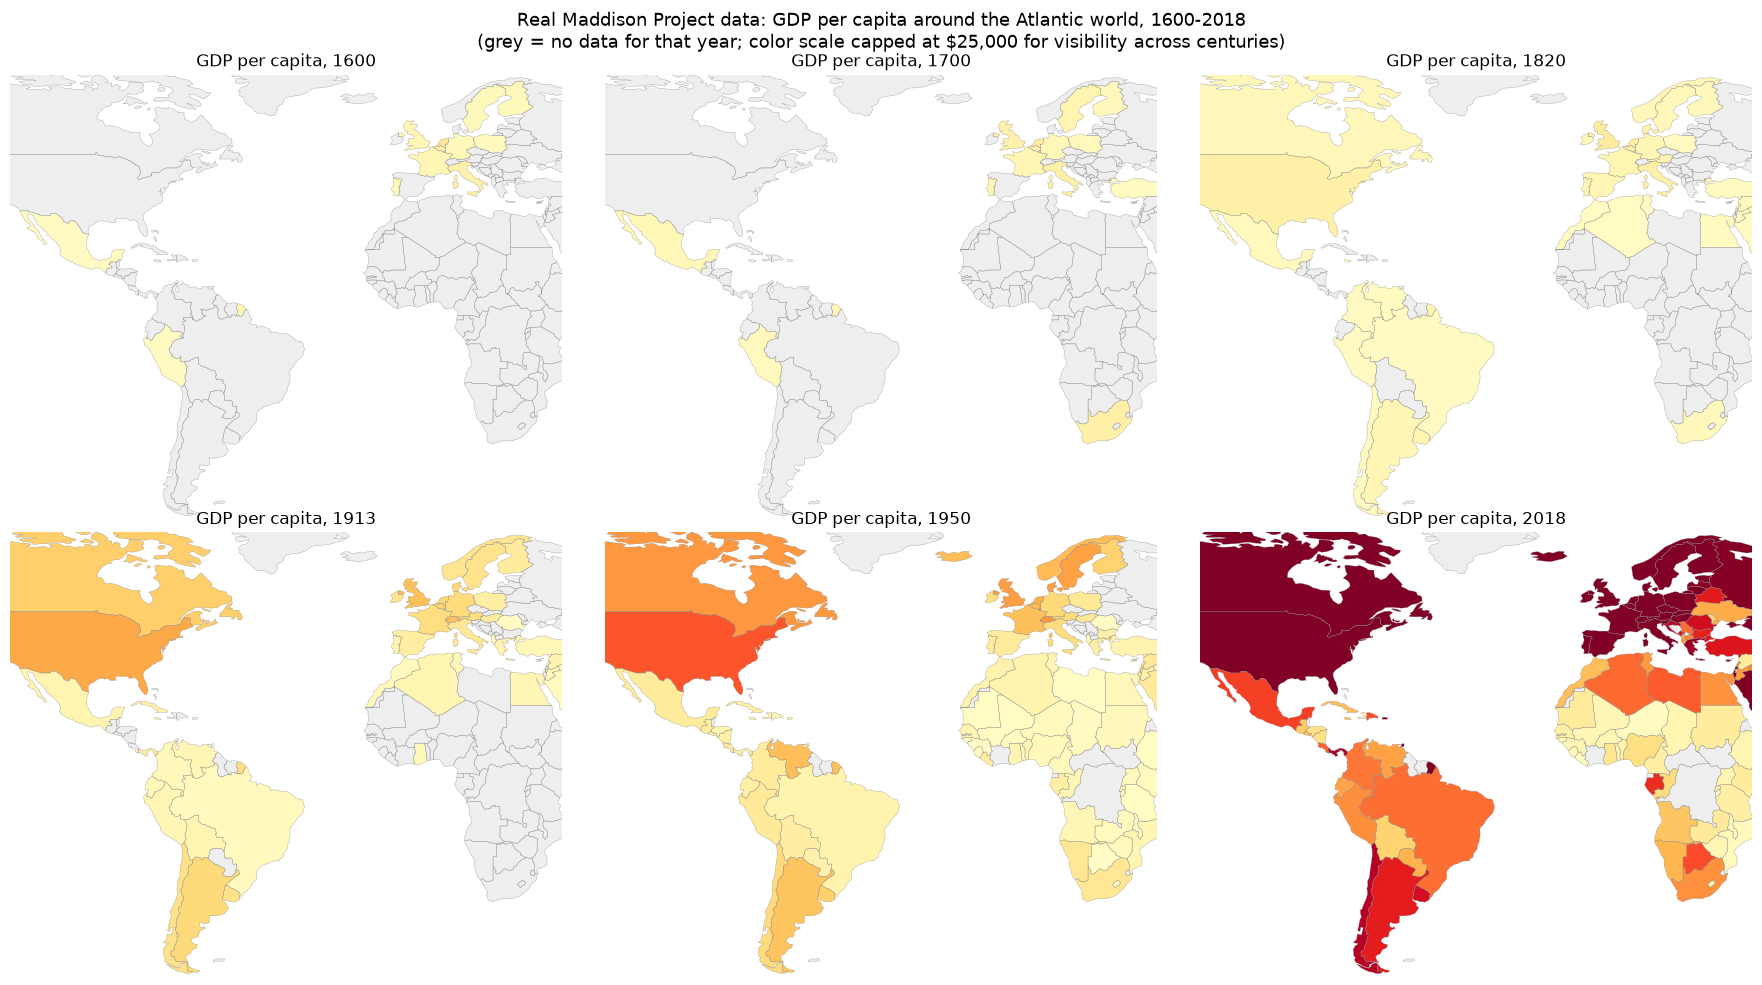

In [4]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

world_ll = world[['NAME', 'geometry']].copy()

for ax, year in zip(axes, benchmark_years):
    yr_data = maddison[maddison['year'] == year][['ne_name', 'gdp_pc']].dropna()
    merged = world_ll.merge(yr_data, left_on='NAME', right_on='ne_name', how='left')
    merged.boundary.plot(ax=ax, linewidth=0.2, color='grey')
    merged.plot(column='gdp_pc', ax=ax, cmap='YlOrRd', legend=False,
                missing_kwds={'color': '#eeeeee'}, vmin=0, vmax=25000)
    # zoom to the Atlantic world: the Americas + Western Europe + West Africa
    ax.set_xlim(-120, 40)
    ax.set_ylim(-56, 72)
    ax.set_title(f'GDP per capita, {year}', fontsize=12)
    ax.set_axis_off()

fig.suptitle('Real Maddison Project data: GDP per capita around the Atlantic world, 1600-2018\n'
             '(grey = no data for that year; color scale capped at $25,000 for visibility across centuries)',
             fontsize=13)
plt.tight_layout()
plt.savefig('fig1_gdp_divergence_map.png', dpi=130, bbox_inches='tight')
plt.show()


By 1600–1700, color intensity is patchy but not obviously North-South stratified. By 1913 and
especially 2018, a sharp color gradient separates Western Europe / North America from Latin
America — exactly the divergence pattern the colonial-extraction and "reversal of fortune"
literatures are trying to explain causally.


## 3. Extraction sites: where the "veins" actually were

Real geographic coordinates for a representative (not exhaustive) set of the major extraction
sites Galeano discusses, organized by the commodity chapters of *Open Veins*: precious metals,
plantation agriculture, and the 19th-20th century commodity booms (guano/nitrates, rubber, tin,
copper, bananas).


In [5]:

extraction_sites = pd.DataFrame([
    # name, lat, lon, commodity, era, country
    ("Potosi",           -19.5836, -65.7531, "Silver",        "1545-1800",  "Bolivia"),
    ("Zacatecas",         22.7709, -102.5832, "Silver",       "1546-1800",  "Mexico"),
    ("Guanajuato",        21.0190, -101.2574, "Silver",       "1550-1810",  "Mexico"),
    ("Ouro Preto (Minas Gerais)", -20.3856, -43.5035, "Gold", "1690-1800", "Brazil"),
    ("Recife (Pernambuco)", -8.0476, -34.8770, "Sugar",       "1550-1700",  "Brazil"),
    ("Salvador da Bahia", -12.9718, -38.5011, "Sugar",        "1550-1700",  "Brazil"),
    ("Havana",             23.1136, -82.3666, "Sugar",        "1750-1900",  "Cuba"),
    ("Manaus",             -3.1019, -60.0250, "Rubber",       "1879-1912",  "Brazil"),
    ("Iquitos",            -3.7437, -73.2516, "Rubber",       "1880-1912",  "Peru"),
    ("Iquique",           -20.2208, -70.1431, "Nitrates/Guano","1830-1930", "Chile"),
    ("Antofagasta",       -23.6509, -70.3975, "Nitrates/Copper","1870-present","Chile"),
    ("Chuquicamata",      -22.3086, -68.9017, "Copper",       "1915-present","Chile"),
    ("Cerro de Pasco",    -10.6844, -76.2531, "Silver/Copper","1600-present", "Peru"),
    ("Oruro (tin belt)",  -17.9833, -67.1500, "Tin",          "1900-1985",  "Bolivia"),
    ("Santa Marta",        11.2408, -74.1990, "Bananas",      "1900-1950",  "Colombia"),
    ("Puerto Barrios",     15.7278, -88.5940, "Bananas",      "1900-1954",  "Guatemala"),
], columns=["site", "lat", "lon", "commodity", "era", "country"])

destination_ports = pd.DataFrame([
    ("Seville/Cadiz", 36.9, -6.0, "Spain (Casa de Contratacion)"),
    ("Lisbon",        38.7, -9.1, "Portugal"),
    ("Liverpool",     53.4, -3.0, "United Kingdom"),
    ("London",        51.5, -0.1, "United Kingdom"),
    ("Amsterdam",      52.4,  4.9, "Netherlands"),
    ("New York",       40.7, -74.0, "United States"),
    ("Boston",         42.4, -71.1, "United States"),
], columns=["port", "lat", "lon", "country"])

commodity_colors = {
    "Silver": "#7f8c8d", "Gold": "#f1c40f", "Sugar": "#e67e22", "Rubber": "#27ae60",
    "Nitrates/Guano": "#8e44ad", "Nitrates/Copper": "#c0392b", "Copper": "#c0392b",
    "Silver/Copper": "#2980b9", "Tin": "#16a085", "Bananas": "#f39c12"
}
extraction_sites['color'] = extraction_sites['commodity'].map(commodity_colors)
extraction_sites


,site,lat,lon,commodity,era,country,color
0,Potosi,-19.5836,-65.7531,Silver,1545-1800,Bolivia,#7f8c8d
1,Zacatecas,22.7709,-102.5832,Silver,1546-1800,Mexico,#7f8c8d
2,Guanajuato,21.0190,-101.2574,Silver,1550-1810,Mexico,#7f8c8d
3,Ouro Preto (Minas Gerais),-20.3856,-43.5035,Gold,1690-1800,Brazil,#f1c40f
4,Recife (Pernambuco),-8.0476,-34.8770,Sugar,1550-1700,Brazil,#e67e22
5,Salvador da Bahia,-12.9718,-38.5011,Sugar,1550-1700,Brazil,#e67e22
6,Havana,23.1136,-82.3666,Sugar,1750-1900,Cuba,#e67e22
7,Manaus,-3.1019,-60.0250,Rubber,1879-1912,Brazil,#27ae60
8,Iquitos,-3.7437,-73.2516,Rubber,1880-1912,Peru,#27ae60
9,Iquique,-20.2208,-70.1431,Nitrates/Guano,1830-1930,Chile,#8e44ad


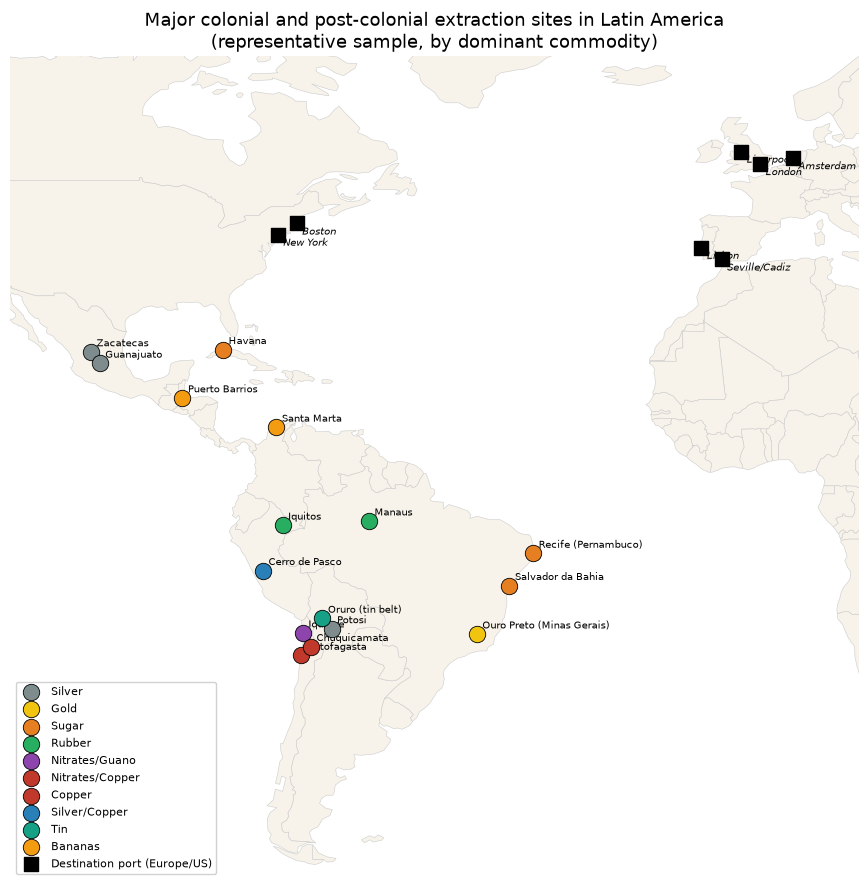

In [6]:

fig, ax = plt.subplots(figsize=(13, 9))
world.plot(ax=ax, color='#f7f3ea', edgecolor='#cccccc', linewidth=0.4)

for commodity, color in commodity_colors.items():
    sub = extraction_sites[extraction_sites['commodity'] == commodity]
    if len(sub):
        ax.scatter(sub['lon'], sub['lat'], s=140, color=color, edgecolor='black',
                   linewidth=0.6, zorder=5, label=commodity)

for _, row in extraction_sites.iterrows():
    ax.annotate(row['site'], (row['lon'], row['lat']), fontsize=7.5,
                xytext=(4, 4), textcoords='offset points')

ax.scatter(destination_ports['lon'], destination_ports['lat'], s=90, color='black',
           marker='s', zorder=5, label='Destination port (Europe/US)')
for _, row in destination_ports.iterrows():
    ax.annotate(row['port'], (row['lon'], row['lat']), fontsize=7.5,
                xytext=(4, -8), textcoords='offset points', style='italic')

ax.set_xlim(-115, 15)
ax.set_ylim(-58, 68)
ax.set_title('Major colonial and post-colonial extraction sites in Latin America\n'
             '(representative sample, by dominant commodity)', fontsize=13)
ax.legend(loc='lower left', fontsize=8, framealpha=0.9)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('fig2_extraction_sites_map.png', dpi=130, bbox_inches='tight')
plt.show()


## 4. Flow map: the "open veins" themselves

This is the visualization Galeano's title literally describes: value flowing out of the
extraction sites toward the imperial centers that ultimately absorbed it. Arcs are stylized
(quadratic-Bezier curves for visual clarity), not literal shipping lanes — but the endpoints
and the site-to-destination pairings are historically grounded (e.g. Potosi/Zacatecas silver to
Seville via the Casa de Contratacion's monopoly; Brazilian sugar and gold to Lisbon; 19th-century
Chilean nitrates and Chuquicamata copper increasingly to Britain and then the US).


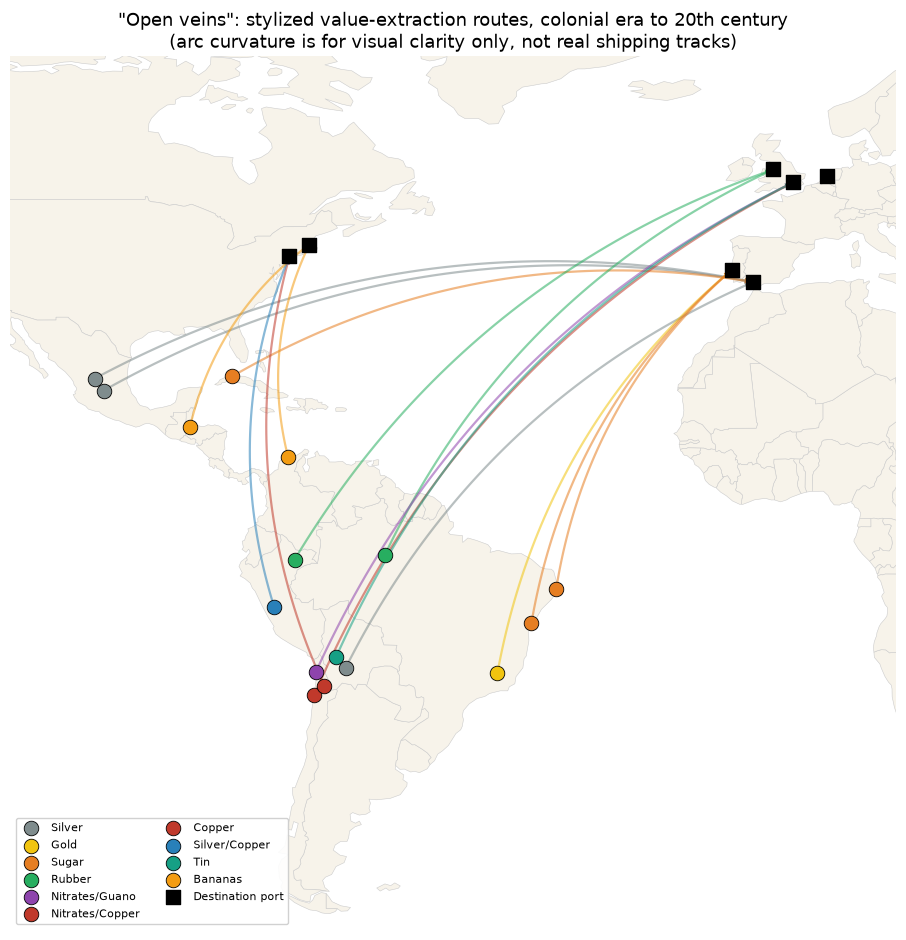

In [7]:

def bezier_arc(lon1, lat1, lon2, lat2, bulge=0.15, n=60):
    # Simple quadratic-Bezier curve between two points, bulging perpendicular
    # to the straight line, purely for visual clarity of overlapping routes.
    mx, my = (lon1 + lon2) / 2, (lat1 + lat2) / 2
    dx, dy = lon2 - lon1, lat2 - lat1
    # perpendicular offset
    px, py = -dy, dx
    norm = np.hypot(px, py) + 1e-9
    cx = mx + bulge * px / norm * np.hypot(dx, dy)
    cy = my + bulge * py / norm * np.hypot(dx, dy)
    t = np.linspace(0, 1, n)
    x = (1 - t)**2 * lon1 + 2 * (1 - t) * t * cx + t**2 * lon2
    y = (1 - t)**2 * lat1 + 2 * (1 - t) * t * cy + t**2 * lat2
    return x, y

# Historically-grounded site -> destination pairings
routes = [
    ("Potosi", "Seville/Cadiz"), ("Zacatecas", "Seville/Cadiz"), ("Guanajuato", "Seville/Cadiz"),
    ("Ouro Preto (Minas Gerais)", "Lisbon"), ("Recife (Pernambuco)", "Lisbon"),
    ("Salvador da Bahia", "Lisbon"), ("Havana", "Seville/Cadiz"),
    ("Manaus", "Liverpool"), ("Iquitos", "Liverpool"),
    ("Iquique", "London"), ("Antofagasta", "London"), ("Chuquicamata", "New York"),
    ("Cerro de Pasco", "New York"), ("Oruro (tin belt)", "London"),
    ("Santa Marta", "Boston"), ("Puerto Barrios", "Boston"),
]

fig, ax = plt.subplots(figsize=(14, 9.5))
world.plot(ax=ax, color='#f7f3ea', edgecolor='#cccccc', linewidth=0.4)

site_lookup = extraction_sites.set_index('site')
port_lookup = destination_ports.set_index('port')

for site_name, port_name in routes:
    s = site_lookup.loc[site_name]
    p = port_lookup.loc[port_name]
    x, y = bezier_arc(s['lon'], s['lat'], p['lon'], p['lat'], bulge=0.18)
    ax.plot(x, y, color=s['color'], alpha=0.55, linewidth=1.6, zorder=3)
    ax.annotate('', xy=(x[-1], y[-1]), xytext=(x[-2], y[-2]),
                arrowprops=dict(arrowstyle='-|>', color=s['color'], alpha=0.7, lw=0), zorder=4)

for commodity, color in commodity_colors.items():
    sub = extraction_sites[extraction_sites['commodity'] == commodity]
    if len(sub):
        ax.scatter(sub['lon'], sub['lat'], s=110, color=color, edgecolor='black',
                   linewidth=0.6, zorder=5, label=commodity)
ax.scatter(destination_ports['lon'], destination_ports['lat'], s=90, color='black',
           marker='s', zorder=5, label='Destination port')

ax.set_xlim(-115, 15)
ax.set_ylim(-58, 70)
ax.set_title('"Open veins": stylized value-extraction routes, colonial era to 20th century\n'
             '(arc curvature is for visual clarity only, not real shipping tracks)', fontsize=13)
ax.legend(loc='lower left', fontsize=8, framealpha=0.9, ncol=2)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('fig3_flow_map.png', dpi=130, bbox_inches='tight')
plt.show()


## 5. Real quantitative data: the trans-Atlantic slave trade

This is the largest single forced-labor "extraction" flow Galeano discusses, and it has by far
the best quantitative documentation of any topic in the book, thanks to the SlaveVoyages.org
project (Eltis, Richardson, et al.), which has digitized ship-level records for over 36,000
voyages. The table below reproduces the project's own published summary estimates by 25-year
period (embarkations from Africa, 1501-1875) — real published numbers, not a simulation.


Total, 1501-1875: 12,521,335 people forcibly exported


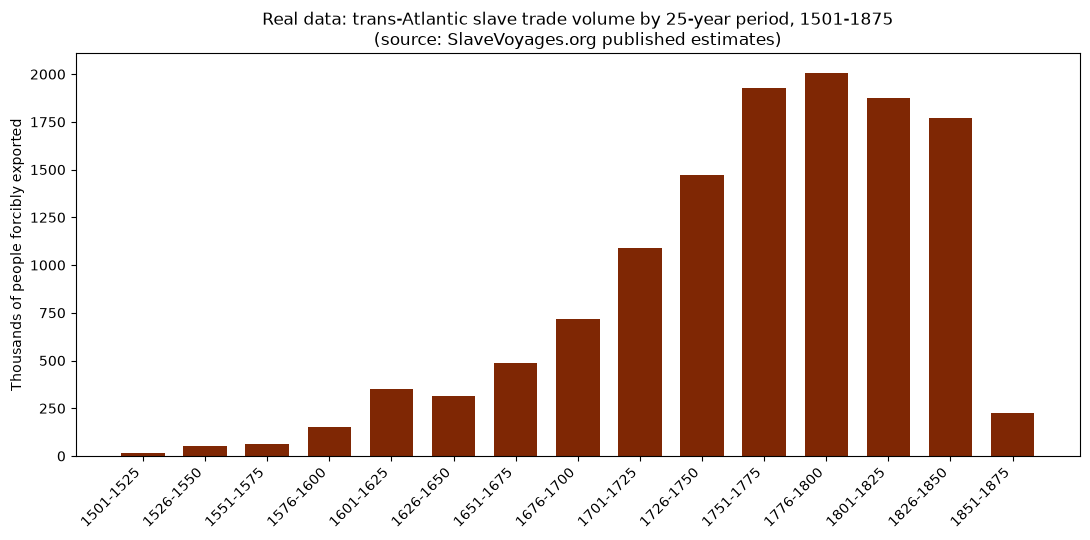

In [8]:

# Real data: SlaveVoyages.org published summary estimates (Estimated African Slave Exports
# to the Americas, 1501-1875), reproduced from the project's own estimates page.
slave_trade_periods = pd.DataFrame([
    ("1501-1525", 13363), ("1526-1550", 50762), ("1551-1575", 61007), ("1576-1600", 152373),
    ("1601-1625", 352842), ("1626-1650", 315050), ("1651-1675", 488064), ("1676-1700", 719675),
    ("1701-1725", 1088908), ("1726-1750", 1471726), ("1751-1775", 1925314), ("1776-1800", 2008670),
    ("1801-1825", 1876992), ("1826-1850", 1770980), ("1851-1875", 225609),
], columns=["period", "total_exported"])
slave_trade_periods['period_start'] = slave_trade_periods['period'].str[:4].astype(int)

print(f"Total, 1501-1875: {slave_trade_periods['total_exported'].sum():,} people forcibly exported")

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(slave_trade_periods['period'], slave_trade_periods['total_exported'] / 1000,
       color='#7f2704', width=0.7)
ax.set_ylabel('Thousands of people forcibly exported')
ax.set_title('Real data: trans-Atlantic slave trade volume by 25-year period, 1501-1875\n(source: SlaveVoyages.org published estimates)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig4_slave_trade_volume.png', dpi=130)
plt.show()


The peak of the trade — nearly 2 million people per 25-year period — falls in the second
half of the 18th century, coinciding almost exactly with the plantation-sugar boom in the
Caribbean and Brazil that Galeano's early chapters describe. This is a case where the historical
narrative and the hard quantitative record line up closely.


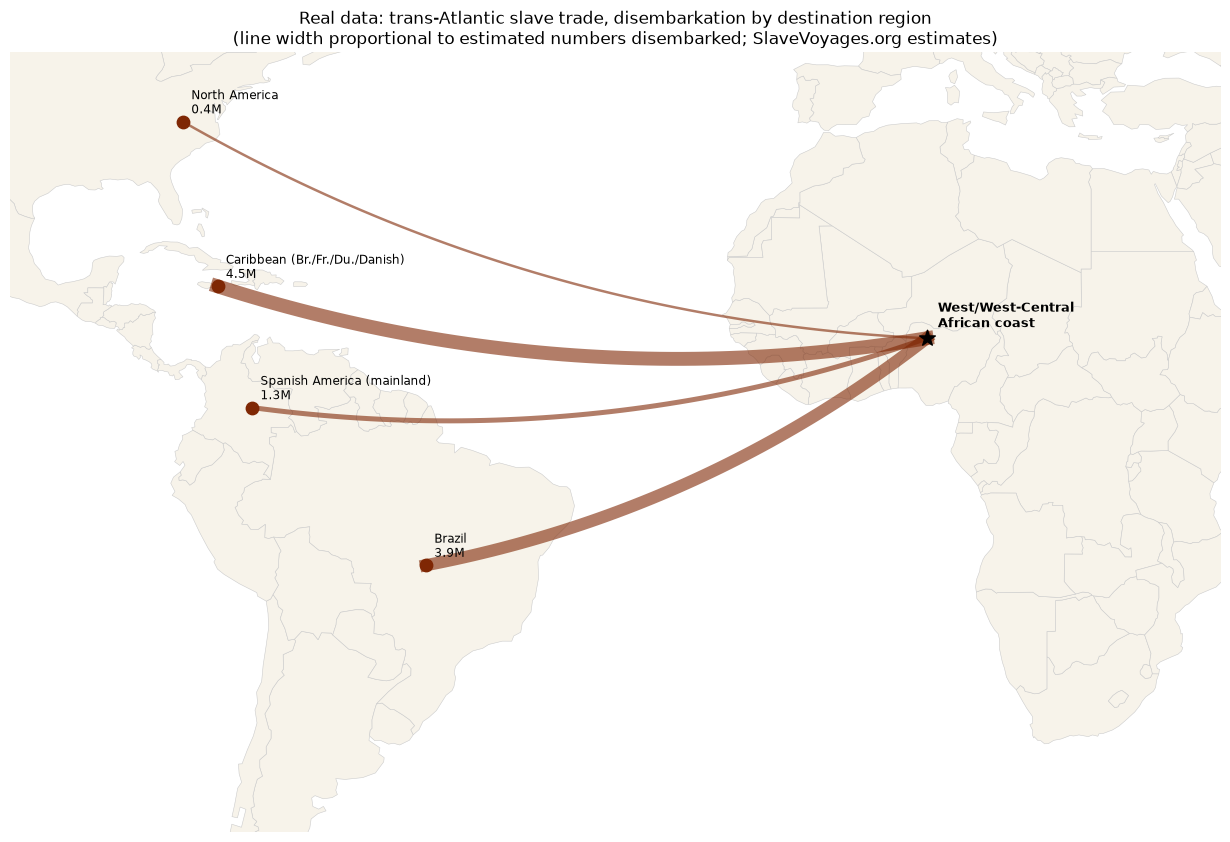

In [9]:

# Real published destination-region shares (SlaveVoyages.org / Eltis & Richardson estimates)
destination_shares = pd.DataFrame([
    ("Brazil",                         3900000, -14.2, -51.9),
    ("Caribbean (Br./Fr./Du./Danish)",  4500000, 18.0, -76.0),
    ("Spanish America (mainland)",      1300000, 4.0, -72.0),
    ("North America",                    400000, 37.0, -80.0),
], columns=["destination", "estimated_disembarked", "lat", "lon"])

origin_point = (6.0, 12.0)  # approx. West/West-Central Africa coastal region (Bight of Benin/Angola)

fig, ax = plt.subplots(figsize=(13, 8.5))
world.plot(ax=ax, color='#f7f3ea', edgecolor='#cccccc', linewidth=0.4)

max_val = destination_shares['estimated_disembarked'].max()
for _, row in destination_shares.iterrows():
    x, y = bezier_arc(origin_point[0], origin_point[1], row['lon'], row['lat'], bulge=0.12)
    lw = 1 + 9 * row['estimated_disembarked'] / max_val
    ax.plot(x, y, color='#7f2704', alpha=0.6, linewidth=lw, zorder=3)
    ax.scatter([row['lon']], [row['lat']], s=80, color='#7f2704', zorder=5)
    ax.annotate(f"{row['destination']}\n{row['estimated_disembarked']/1e6:.1f}M",
                (row['lon'], row['lat']), fontsize=8.5, xytext=(6, 6), textcoords='offset points')

ax.scatter(*origin_point, s=140, color='black', marker='*', zorder=6)
ax.annotate('West/West-Central\nAfrican coast', origin_point, fontsize=9, fontweight='bold',
            xytext=(8, 8), textcoords='offset points')

ax.set_xlim(-100, 40)
ax.set_ylim(-45, 45)
ax.set_title('Real data: trans-Atlantic slave trade, disembarkation by destination region\n'
             '(line width proportional to estimated numbers disembarked; SlaveVoyages.org estimates)',
             fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('fig5_slave_trade_destinations.png', dpi=130, bbox_inches='tight')
plt.show()


## 6. Synthesis map

Overlaying the GDP-divergence choropleth (2018) with both extraction-flow layers gives a single
picture connecting the historical mechanism Galeano describes to its modern quantitative
outcome.


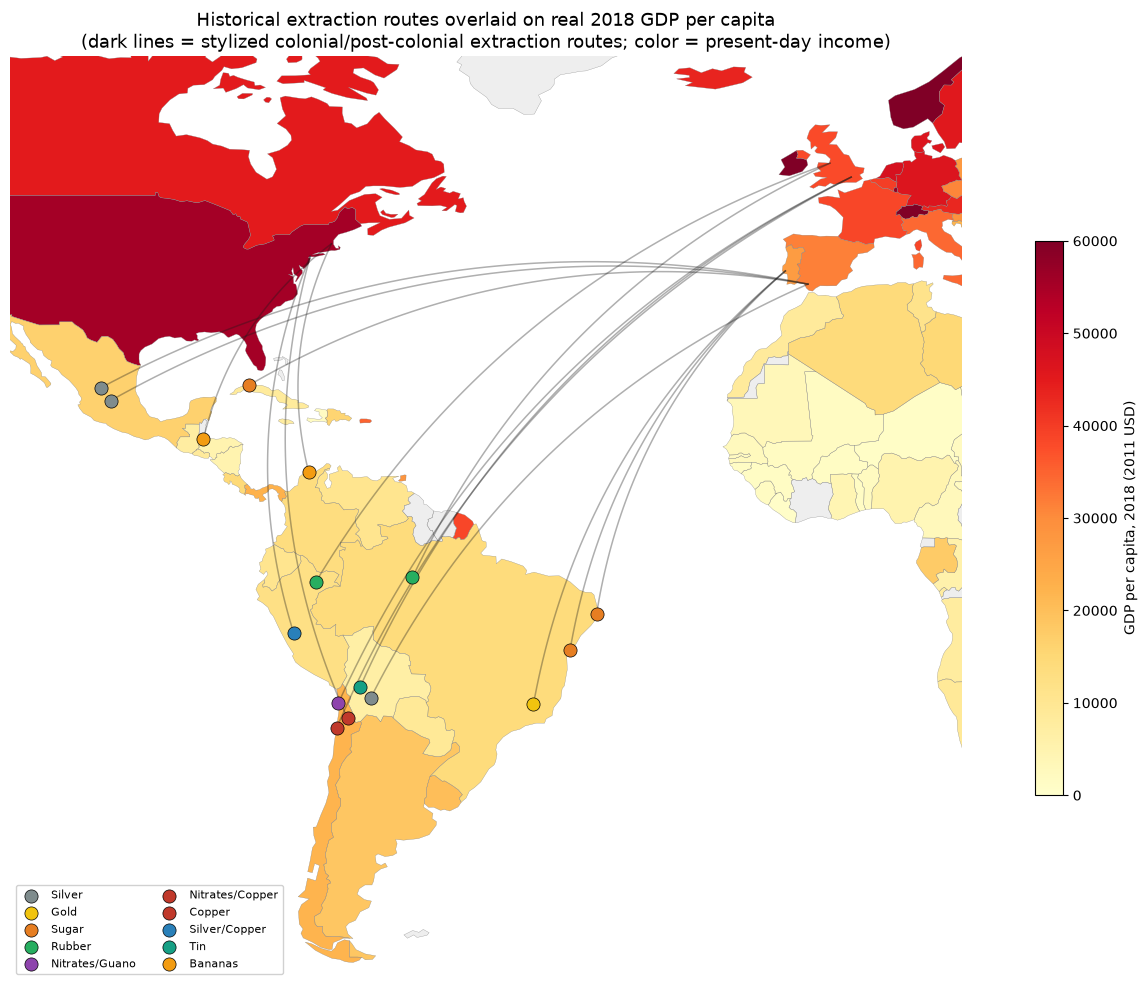

In [10]:

fig, ax = plt.subplots(figsize=(15, 10))

yr_data = maddison[maddison['year'] == 2018][['ne_name', 'gdp_pc']].dropna()
merged = world_ll.merge(yr_data, left_on='NAME', right_on='ne_name', how='left')
merged.boundary.plot(ax=ax, linewidth=0.2, color='grey')
merged.plot(column='gdp_pc', ax=ax, cmap='YlOrRd', legend=True,
            missing_kwds={'color': '#eeeeee'}, vmin=0, vmax=60000,
            legend_kwds={'label': 'GDP per capita, 2018 (2011 USD)', 'shrink': 0.6})

for site_name, port_name in routes:
    s = site_lookup.loc[site_name]
    p = port_lookup.loc[port_name]
    x, y = bezier_arc(s['lon'], s['lat'], p['lon'], p['lat'], bulge=0.18)
    ax.plot(x, y, color='#1a1a1a', alpha=0.35, linewidth=1.1, zorder=3)

for commodity, color in commodity_colors.items():
    sub = extraction_sites[extraction_sites['commodity'] == commodity]
    if len(sub):
        ax.scatter(sub['lon'], sub['lat'], s=90, color=color, edgecolor='black',
                   linewidth=0.5, zorder=5, label=commodity)

ax.set_xlim(-115, 15)
ax.set_ylim(-58, 68)
ax.set_title('Historical extraction routes overlaid on real 2018 GDP per capita\n'
             '(dark lines = stylized colonial/post-colonial extraction routes; color = present-day income)',
             fontsize=13)
ax.legend(loc='lower left', fontsize=8, framealpha=0.9, ncol=2)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('fig6_synthesis_map.png', dpi=130, bbox_inches='tight')
plt.show()


## 7. What this notebook does and doesn't establish

**What's genuinely shown:** the real Maddison GDP data confirms a large and growing North-South
income gap across the exact period the extraction routes were most active; the real SlaveVoyages
data confirms the scale and destination pattern of the largest forced-labor flow; the geography
of the extraction sites genuinely corresponds to the commodities Galeano organizes his chapters
around.

**What this notebook does *not* establish:** correlation in time and geography is not a causal
estimate. The map juxtaposes two real datasets and a stylized flow layer — it does not run a
regression, an instrumental-variables design, or a formal unequal-exchange calculation the way
Acemoglu-Johnson-Robinson or Hickel et al. do. A rigorous next step would be to attach an actual
extraction *value* estimate (e.g. TePaske's bullion registers, or export-tax records for nitrates
and rubber) to each site and formally test whether higher historical extraction intensity
predicts the size of the modern income gap — a proper cross-sectional regression, not a map.
